#### Extract gene signatures from Ishikawa et al., 2022 LGR5+/- stem cells
- **Developed by:** Anna Maguza
- **Affilation:** Faculty of Medicine, Würzburg University
- **Date of creation:** 4th October 2024
- **Last modified date:** 15th November 2024

This notebook is created to extract gene signatures from Ishikawa et al., 2022 LGR5+/- stem cells.

+ Import packages

In [28]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime

In [2]:
def X_is_raw(adata):
    return np.array_equal(adata.X.sum(axis=0).astype(int), adata.X.sum(axis=0))

### Analyze signatures of Ishikawa, 2022 stem cells

+ Load Ishikawa object

In [3]:
adult_adata = sc.read_h5ad("data/Ishikawa_2022/gut_hs_Ishikawa2022_AM_15112024_120658_raw.h5ad")

/home/amaguza/.local/share/hatch/env/virtual/single-cell-project/HC5eoTg7/single_cell_project/lib/python3.10/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


+ Normalize and log transform

In [4]:
adult_adata_copy = adult_adata.copy()
sc.pp.normalize_total(adult_adata, target_sum = 1e6, exclude_highly_expressed = True) 
sc.pp.log1p(adult_adata)

+ Check the LGR5 and other stem cells markers expression in the dataset 

In [5]:
adult_adata.var.index = adult_adata.var['gene_name'].copy()

In [6]:
stem_cells_features = ['LGR5', 'SMOC2', 'ASCL2', 'AXIN2']

In [7]:
# make var names not categorical
adult_adata.var['gene_name'] = adult_adata.var['gene_name'].astype(str)
adult_adata.var.index = adult_adata.var['gene_name'].copy()

# make var names unique
adult_adata.var_names_make_unique()

In [8]:
sc.tl.score_genes(adult_adata, gene_list=stem_cells_features, score_name='ISC_score')

In [9]:
lgr5_features = ['LGR5']

In [10]:
sc.tl.score_genes(adult_adata, gene_list=lgr5_features, score_name='LGR5_score')

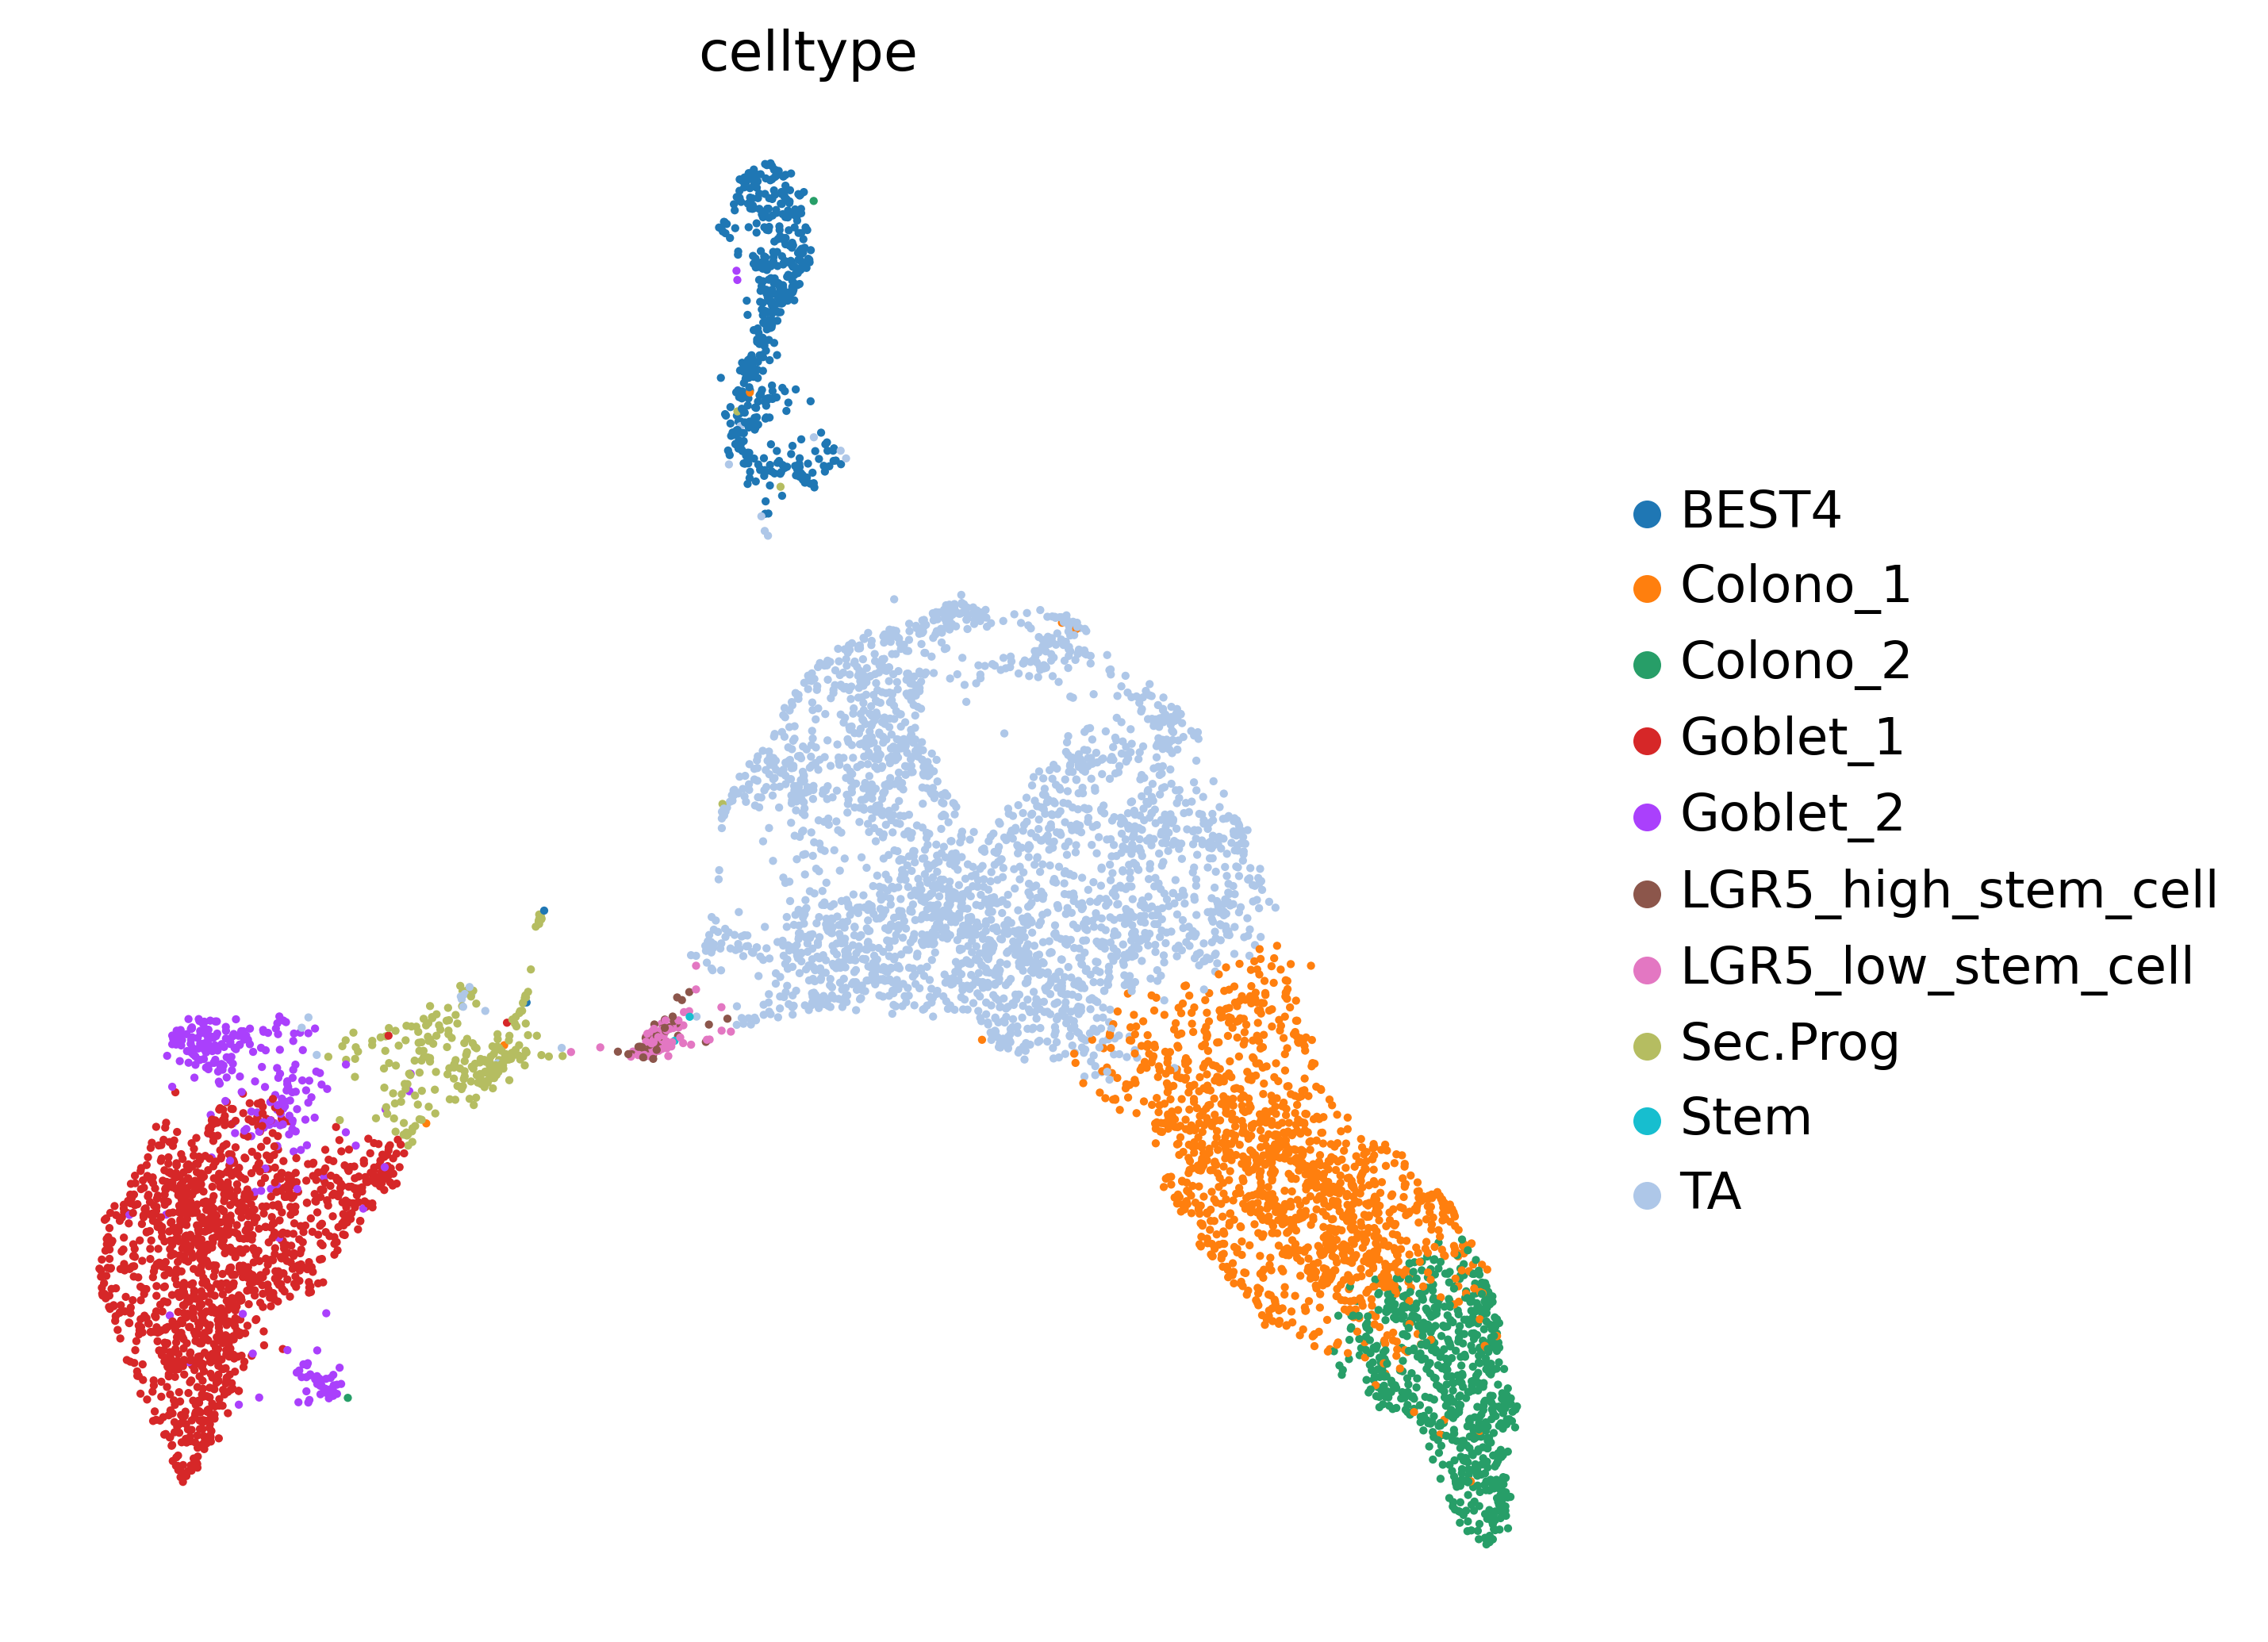

In [27]:
sc.set_figure_params(figsize=(7, 7), dpi=180)
sc.pl.umap(adult_adata, color=['celltype'], frameon = False, ncols=3)

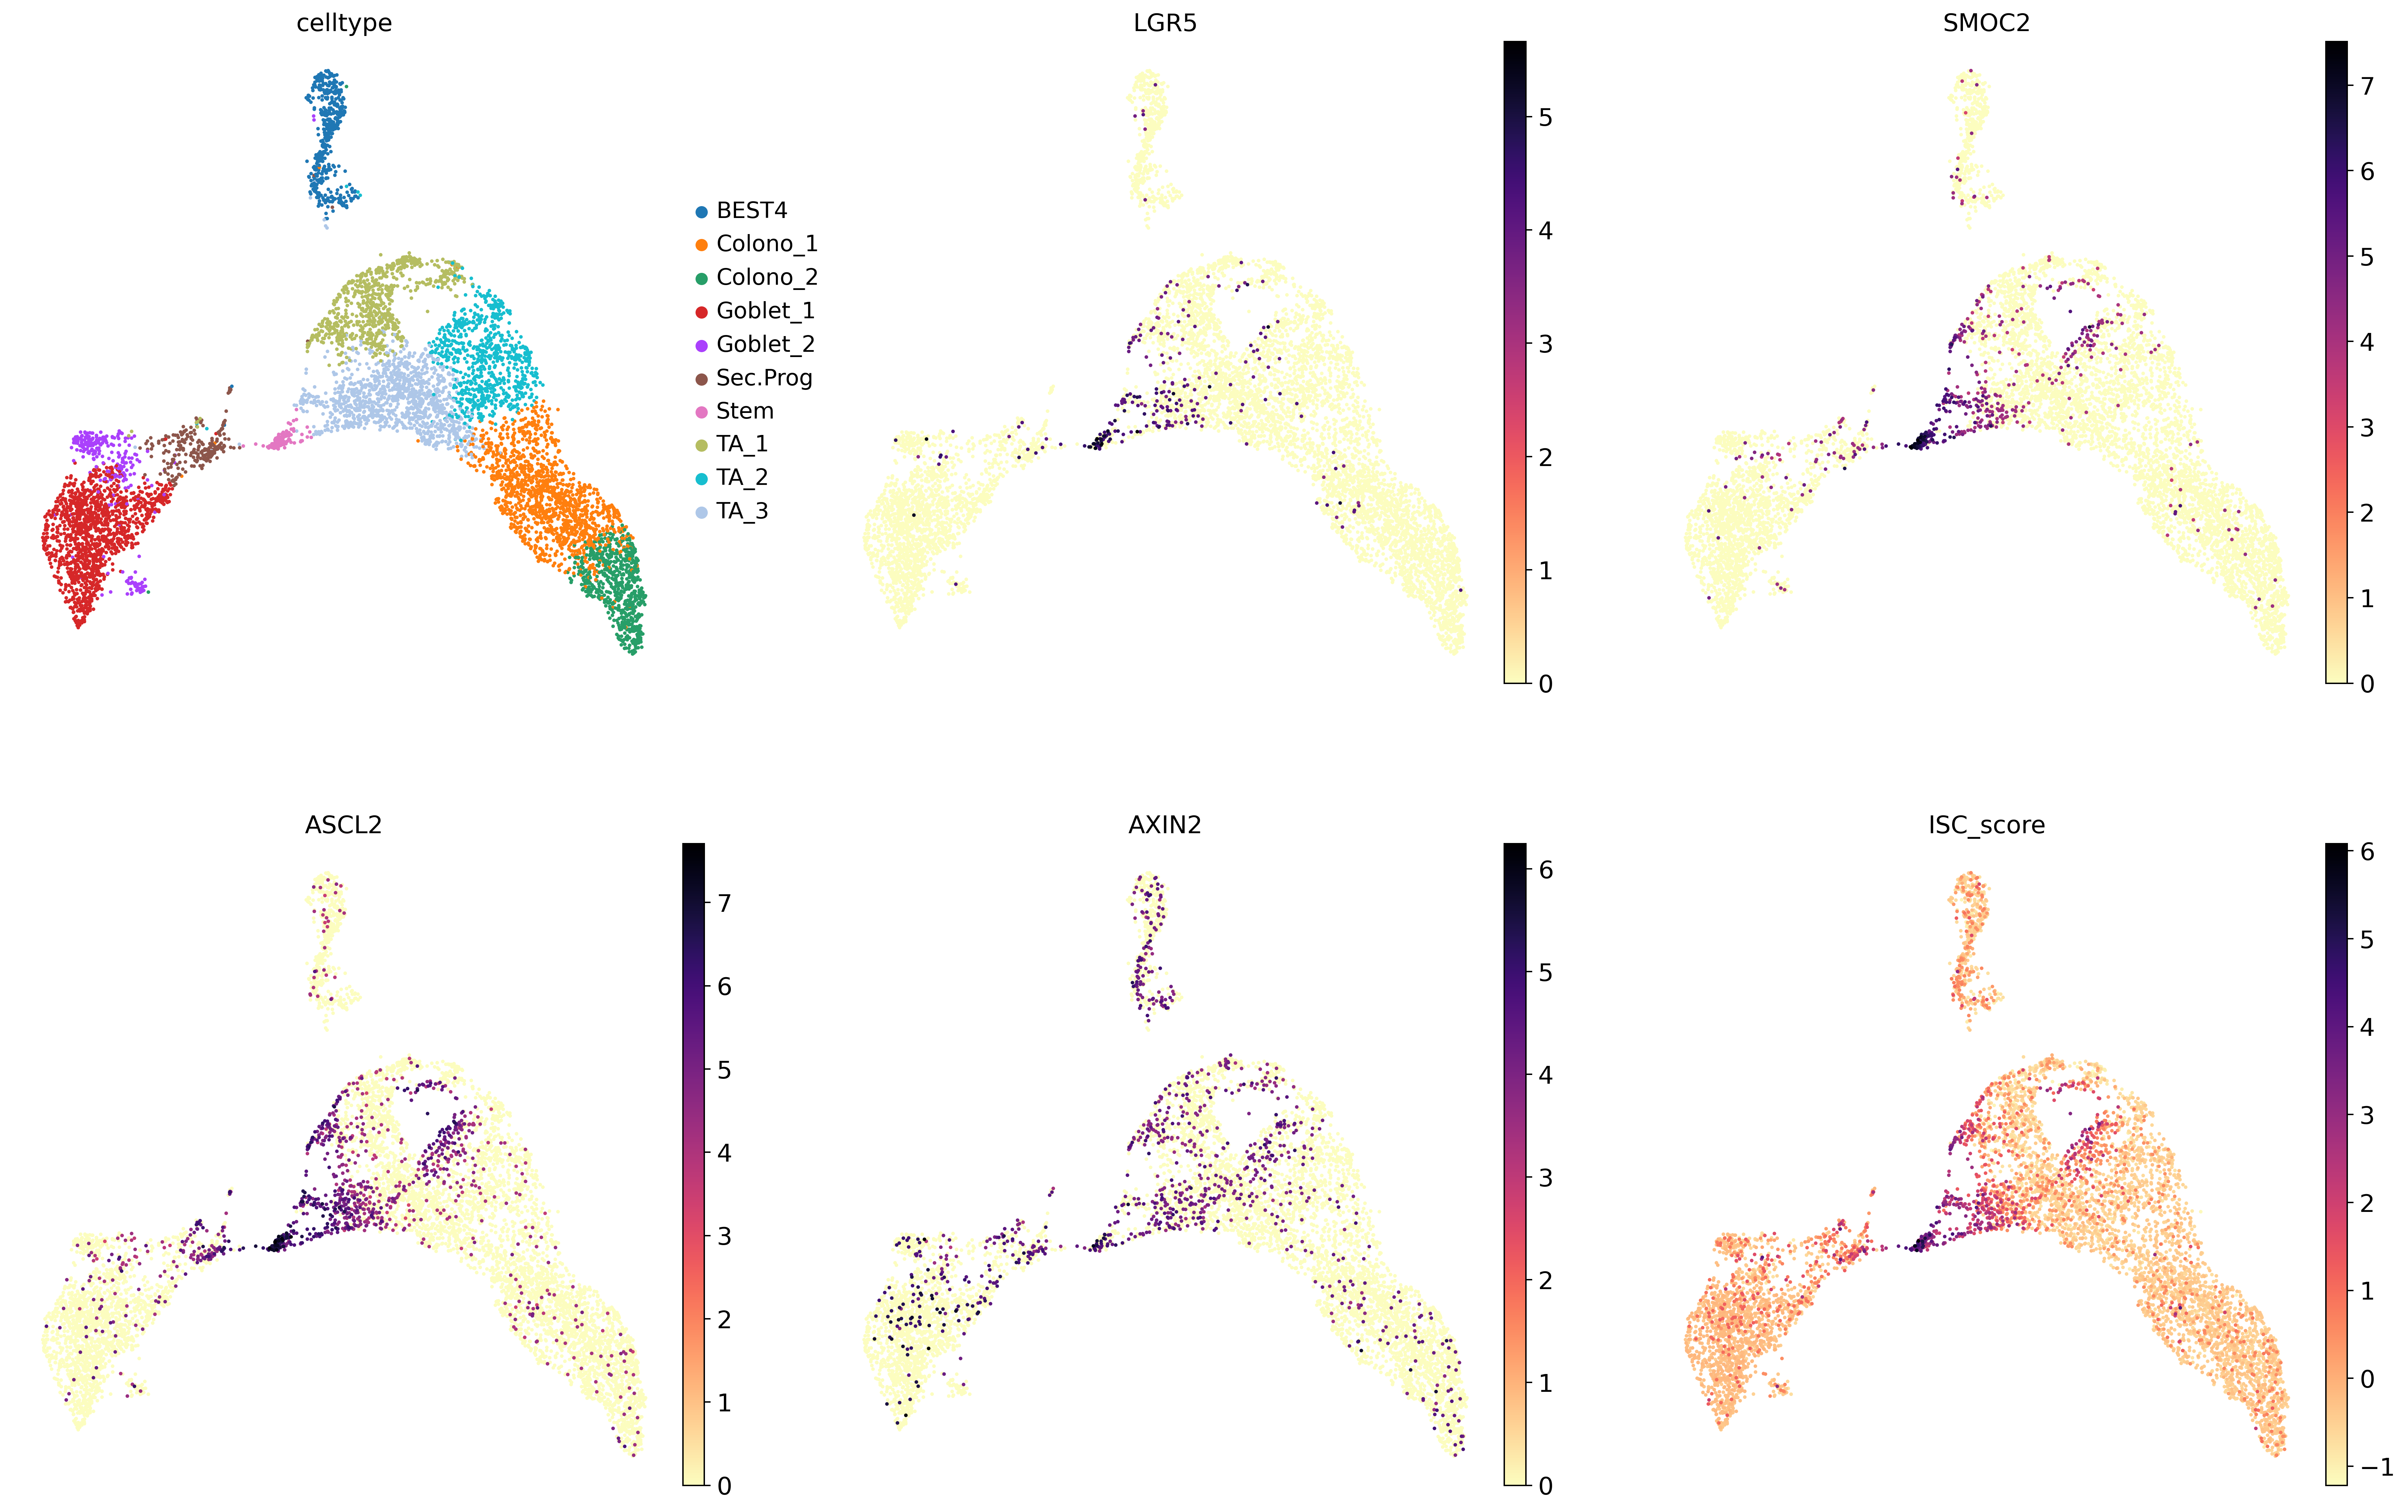

In [11]:
sc.set_figure_params(figsize=(7, 7), dpi=180)
sc.pl.umap(adult_adata, color=['celltype', 'LGR5', 'SMOC2', 'ASCL2', 'AXIN2', 'ISC_score'], color_map='magma_r', frameon = False, ncols=3)

In [12]:
adult_adata.obs['LGR5+'] = adult_adata.obs['LGR5_score'] > 3
adult_adata.obs['ISC_high'] = adult_adata.obs['ISC_score'] > 3

In [13]:
adult_adata.obs['LGR5+'] = adult_adata.obs['LGR5+'].astype(str)
adult_adata.obs['ISC_high'] = adult_adata.obs['ISC_high'].astype(str)
adult_adata.obs['celltype'] = adult_adata.obs['celltype'].astype(str)
adult_adata.obs['extended_annotation'] = adult_adata.obs['celltype'] + '_' + adult_adata.obs['LGR5+'] + '_' + adult_adata.obs['ISC_high']

In [14]:
adult_adata.obs.loc[adult_adata.obs['extended_annotation'] == 'Stem_True_True', 'celltype'] = 'LGR5_high_stem_cell'
adult_adata.obs.loc[adult_adata.obs['celltype'] == 'TA_1', 'celltype'] = 'TA'
adult_adata.obs.loc[adult_adata.obs['celltype'] == 'TA_2', 'celltype'] = 'TA'
adult_adata.obs.loc[adult_adata.obs['celltype'] == 'TA_3', 'celltype'] = 'TA'

In [15]:
adult_adata.obs['celltype'].value_counts()

celltype
TA                     2626
Colono_1               1358
Goblet_1               1346
Colono_2                676
BEST4                   469
Goblet_2                285
Sec.Prog                235
Stem                     69
LGR5_high_stem_cell      39
Name: count, dtype: int64

In [16]:
adult_adata.obs.loc[(adult_adata.obs['celltype'] == 'Stem') & (adult_adata.obs['LGR5_score'] < 1), 'celltype'] = 'LGR5_low_stem_cell'
adult_adata.obs['celltype'].value_counts()

celltype
TA                     2626
Colono_1               1358
Goblet_1               1346
Colono_2                676
BEST4                   469
Goblet_2                285
Sec.Prog                235
LGR5_low_stem_cell       67
LGR5_high_stem_cell      39
Stem                      2
Name: count, dtype: int64

+ Extract signature stem cells genes from Ishikawa, 2022 study

In [23]:
filtered_adata = adult_adata[adult_adata.obs['celltype'].isin(['LGR5_high_stem_cell', 'LGR5_low_stem_cell'])]

In [24]:
filtered_adata.obs['celltype'].value_counts()

celltype
LGR5_low_stem_cell     67
LGR5_high_stem_cell    39
Name: count, dtype: int64

In [25]:
sc.tl.rank_genes_groups(filtered_adata, groupby="celltype", method='wilcoxon', n_genes=100)
adult_df_wilcoxon = sc.get.rank_genes_groups_df(filtered_adata, group=None)

/home/amaguza/.local/share/hatch/env/virtual/single-cell-project/HC5eoTg7/single_cell_project/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:645: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


In [26]:
sc.tl.rank_genes_groups(filtered_adata, groupby="celltype", method='logreg', n_genes=100)
adult_df_logreg = sc.get.rank_genes_groups_df(filtered_adata, group=None)

+ Save list of DEGs

In [29]:
project = 'gut'
species = 'hs'
atribute = 'Ishikawa2022_LGR5+vsLGR5-_DEGs_wilcoxon'
name = 'AM'
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')

adult_df_wilcoxon.to_csv(f"data/Ishikawa_2022/{project}_{species}_{atribute}_{name}_{timestamp}.csv")

In [30]:
atribute = 'Ishikawa2022_LGR5+vsLGR5-_DEGs_logreg'
adult_df_logreg.to_csv(f"data/Ishikawa_2022/{project}_{species}_{atribute}_{name}_{timestamp}.csv")